In [59]:
# import API for Glove matrices
try:
  import gensim.downloader as api
except:
  !pip install gensim
  import gensim.downloader as api

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

import sklearn
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

from transformers import GPT2Tokenizer, GPT2Model
from transformers import logging

In [60]:
# Import Word2Vec and GPT2 models
w2v = api.load("word2vec-google-news-300")

# Import GPT2 model and tokenizer
logging.set_verbosity_error()

gpt2 = GPT2Model.from_pretrained('gpt2')
gpt_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

gpt_embedding = gpt2.wte.weight.detach().numpy()
#

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [61]:
# Find first 100 matching tokens between word2vec and gpt2
w2v_tokens = list(w2v.key_to_index.keys())
gpt2_tokens = [gpt_tokenizer.decode(i) for i in range(gpt_tokenizer.vocab_size)]

In [62]:
matching_text = []
for token in w2v_tokens:
  if len(token)> 5 and token in gpt2_tokens:
    matching_text.append(token)

    if len(matching_text) > 99:
      break

width = max(len(t) for t in matching_text)

for tok in matching_text:
    w2v_idx = w2v.key_to_index[tok]
    gpt_id  = gpt_tokenizer.encode(tok)[0]
    print(f'The word "{tok:<{width}}" appears in index 'f'{w2v_idx:>5} in Word2Vec and {gpt_id:>6} in GPT-2')

The word "people     " appears in index    68 in Word2Vec and  15332 in GPT-2
The word "million    " appears in index    81 in Word2Vec and  14100 in GPT-2
The word "percent    " appears in index    90 in Word2Vec and  25067 in GPT-2
The word "because    " appears in index    96 in Word2Vec and  13893 in GPT-2
The word "before     " appears in index    99 in Word2Vec and  19052 in GPT-2
The word "company    " appears in index   100 in Word2Vec and  39722 in GPT-2
The word "against    " appears in index   103 in Word2Vec and  32826 in GPT-2
The word "through    " appears in index   108 in Word2Vec and   9579 in GPT-2
The word "second     " appears in index   110 in Word2Vec and  12227 in GPT-2
The word "season     " appears in index   114 in Word2Vec and   6230 in GPT-2
The word "government " appears in index   121 in Word2Vec and  14480 in GPT-2
The word "should     " appears in index   130 in Word2Vec and  21754 in GPT-2
The word "during     " appears in index   135 in Word2Vec and  4

In [63]:
embedding_w2v = np.array([w2v[tok] for tok in matching_text])
embedding_gpt = np.array([gpt_embedding[gpt_tokenizer.encode(tok)[0]] for tok in matching_text])

print(f'Size of Word2Vec embedding: {embedding_w2v.shape}')
print(f'Size of GPT-2 embedding: {embedding_gpt.shape}')

Size of Word2Vec embedding: (100, 300)
Size of GPT-2 embedding: (100, 768)


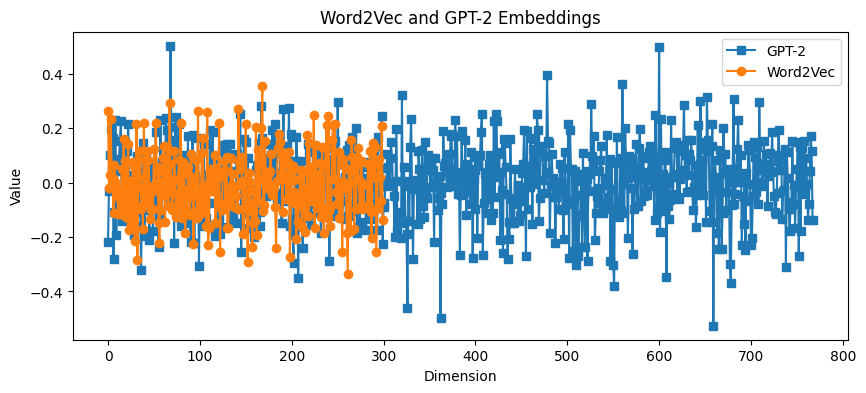

In [64]:
plt.figure(figsize=(10,4))
plt.plot(range(embedding_gpt.shape[1]), embedding_gpt[0,:], 's-',label='GPT-2')
plt.plot(range(embedding_w2v.shape[1]), embedding_w2v[0,:], 'o-',label='Word2Vec')
plt.xlabel('Dimension')
plt.ylabel('Value')
plt.title('Word2Vec and GPT-2 Embeddings')
plt.legend()
plt.show()

# Cosine Similarities of the embedding matrices

In [65]:
# Using scikit-learn
sc_w2v = cosine_similarity(embedding_w2v)
sc_gpt = cosine_similarity(embedding_gpt)

sc_w2v_std = cosine_similarity(StandardScaler().fit_transform(embedding_w2v))
sc_gpt_std = cosine_similarity(StandardScaler().fit_transform(embedding_gpt))

# Using manual method
w2v_norm = embedding_w2v / np.linalg.norm(embedding_w2v, axis=1, keepdims=True)
gpt_norm = embedding_gpt / np.linalg.norm(embedding_gpt, axis=1, keepdims=True)

sc_w2v_manual = w2v_norm @ w2v_norm.T
sc_gpt_manual = gpt_norm @ gpt_norm.T

# Compare between the two methods
sc_w2v_diff = sc_w2v - sc_w2v_manual
sc_gpt_diff = sc_gpt - sc_gpt_manual

print("w2v max abs diff:", np.max(np.abs(sc_w2v - sc_w2v_manual)))
print("gpt max abs diff:", np.max(np.abs(sc_gpt - sc_gpt_manual)))

np.isclose(sc_w2v_diff, 0, atol=1e-6).all(), np.isclose(sc_gpt_diff, 0, atol=1e-6).all()


w2v max abs diff: 4.7683716e-07
gpt max abs diff: 4.7683716e-07


(np.True_, np.True_)

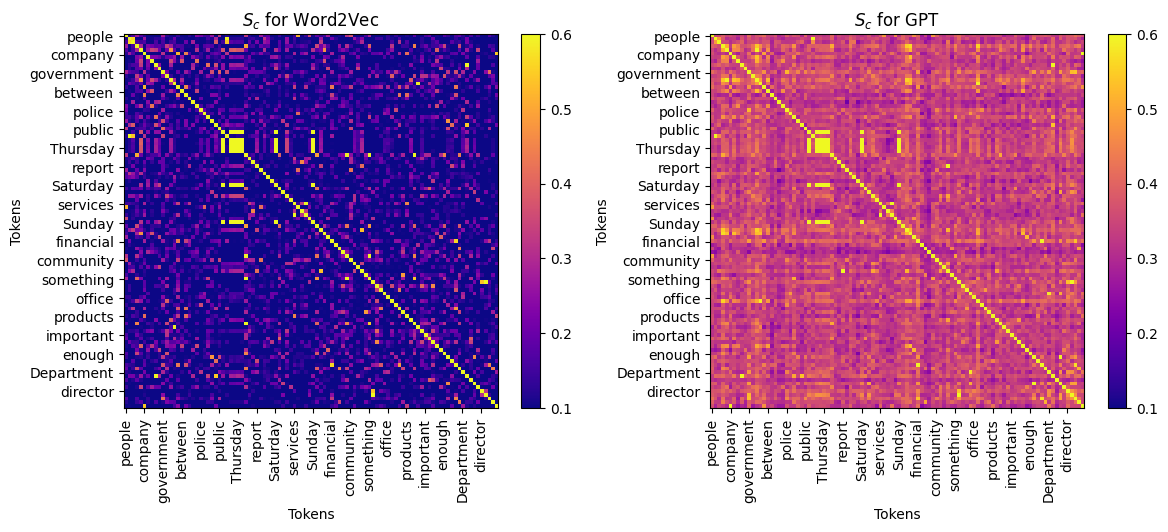

In [66]:
# Visualize the cosine similarities of the two mtrices
fig, axs = plt.subplots(1,2, figsize=(12,5))

# im = axs[0].imshow(sc_w2v_std, vmin=.1, vmax=.6,cmap='plasma', interpolation='nearest')
# im = axs[0].imshow(sc_w2v_manual, vmin=.1, vmax=.6,cmap='plasma', interpolation='nearest')
im = axs[0].imshow(sc_w2v, vmin=.1, vmax=.6,cmap='plasma', interpolation='nearest')
axs[0].set_title('$S_c$ for Word2Vec')
axs[0].set(xlabel='Tokens', ylabel='Tokens')
axs[0].set_xticks(np.arange(0,len(matching_text),5), labels=matching_text[::5], rotation=90)
axs[0].set_yticks(np.arange(0,len(matching_text),5), labels=matching_text[::5])
plt.colorbar(im, ax=axs[0])

# im = axs[1].imshow(sc_gpt_std, vmin=.1, vmax=.6,cmap='plasma', interpolation='nearest')
# im = axs[1].imshow(sc_gpt_manual, vmin=.1, vmax=.6,cmap='plasma', interpolation='nearest')
im = axs[1].imshow(sc_gpt, vmin=.1, vmax=.6,cmap='plasma', interpolation='nearest')
axs[1].set_title('$S_c$ for GPT')
axs[1].set(xlabel='Tokens', ylabel='Tokens')
axs[1].set_xticks(np.arange(0,len(matching_text),5), labels=matching_text[::5], rotation=90)
axs[1].set_yticks(np.arange(0,len(matching_text),5), labels=matching_text[::5])
plt.colorbar(im, ax=axs[1])

plt.tight_layout()
plt.show()

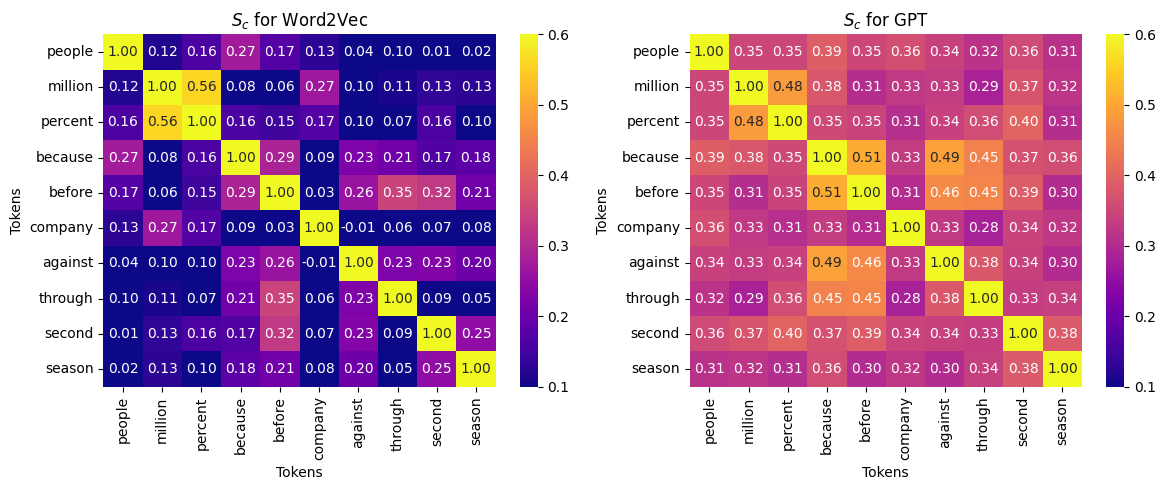

In [67]:
# Cosine similarity matrices
sc_w2v = sklearn.metrics.pairwise.cosine_similarity(embedding_w2v)
sc_gpt = sklearn.metrics.pairwise.cosine_similarity(embedding_gpt)

# Put into DataFrames so seaborn can keep indices (optional)
df_sc_w2v = pd.DataFrame(sc_w2v)
df_sc_gpt = pd.DataFrame(sc_gpt)

# Visualize through seaborn heatmap
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

k = 10
matching_k = matching_text[:k]

# For readability: don't annotate 100x100
sns.heatmap(df_sc_w2v.iloc[:k, :k], ax=axs[0], cmap='plasma', vmin=.1, vmax=.6, annot=True, xticklabels=matching_k, yticklabels=matching_k, fmt='.2f')
axs[0].set_title('$S_c$ for Word2Vec')
axs[0].set(xlabel='Tokens', ylabel='Tokens')

sns.heatmap(df_sc_gpt.iloc[:k,:k], ax=axs[1], cmap='plasma', vmin=.1, vmax=.6, annot=True, xticklabels=matching_k, yticklabels=matching_k, fmt='.2f')
axs[1].set_title('$S_c$ for GPT')
axs[1].set(xlabel='Tokens', ylabel='Tokens')

plt.tight_layout()
plt.show()

In [68]:
def mean_offdiag(S):
    n = S.shape[0]
    return (S.sum() - np.trace(S)) / (n*(n-1))

print("Mean off-diagonal similarity:")
print("Word2Vec:", mean_offdiag(sc_w2v))
print("GPT-2   :", mean_offdiag(sc_gpt))


Mean off-diagonal similarity:
Word2Vec: 0.10914987
GPT-2   : 0.34925297


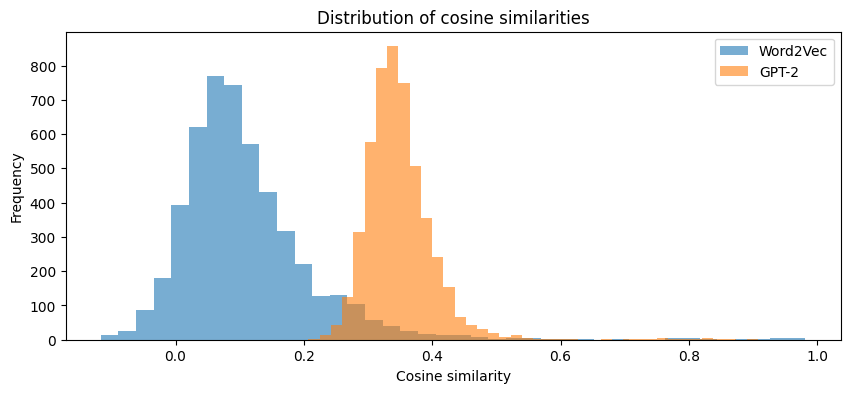

In [69]:
plt.figure(figsize=(10,4))

plt.hist(sc_w2v[np.triu_indices_from(sc_w2v, k=1)],
         bins=40, alpha=0.6, label="Word2Vec")

plt.hist(sc_gpt[np.triu_indices_from(sc_gpt, k=1)],
         bins=40, alpha=0.6, label="GPT-2")

plt.legend()
plt.title("Distribution of cosine similarities")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.show()


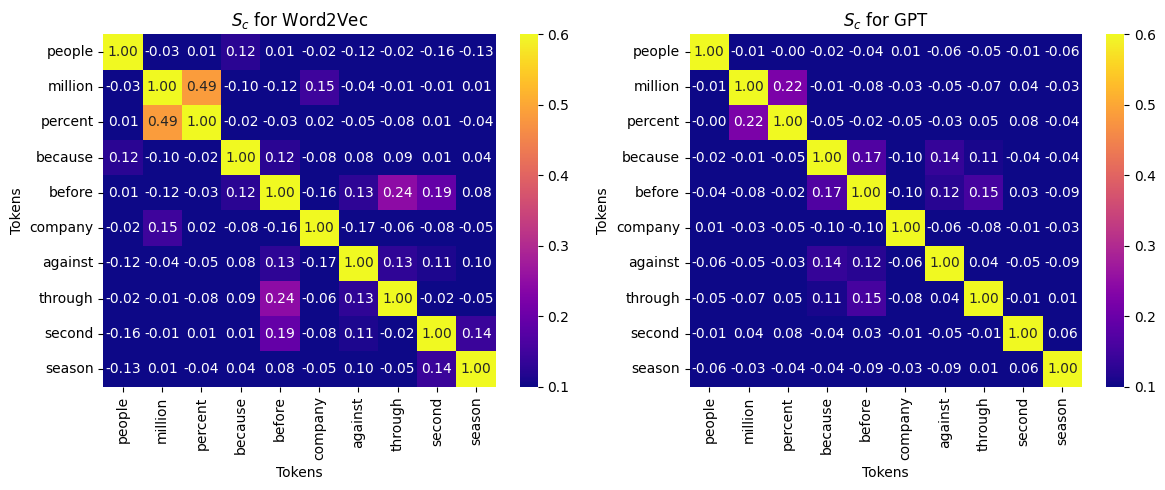

In [84]:
# Cosine similarity matrices with mean centered data
sc_w2v_centered = sklearn.metrics.pairwise.cosine_similarity(w2v_centered)
sc_gpt_centered = sklearn.metrics.pairwise.cosine_similarity(gpt_centered)

# Put into DataFrames so seaborn can keep indices (optional)
df_sc_w2v = pd.DataFrame(sc_w2v_centered)
df_sc_gpt = pd.DataFrame(sc_gpt_centered)

# Visualize through seaborn heatmap
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

k = 10
matching_k = matching_text[:k]

# For readability: don't annotate 100x100
sns.heatmap(df_sc_w2v.iloc[:k, :k], ax=axs[0], cmap='plasma', vmin=.1, vmax=.6, annot=True, xticklabels=matching_k, yticklabels=matching_k, fmt='.2f')
axs[0].set_title('$S_c$ for Word2Vec')
axs[0].set(xlabel='Tokens', ylabel='Tokens')

sns.heatmap(df_sc_gpt.iloc[:k,:k], ax=axs[1], cmap='plasma', vmin=.1, vmax=.6, annot=True, xticklabels=matching_k, yticklabels=matching_k, fmt='.2f')
axs[1].set_title('$S_c$ for GPT')
axs[1].set(xlabel='Tokens', ylabel='Tokens')

plt.tight_layout()
plt.show()

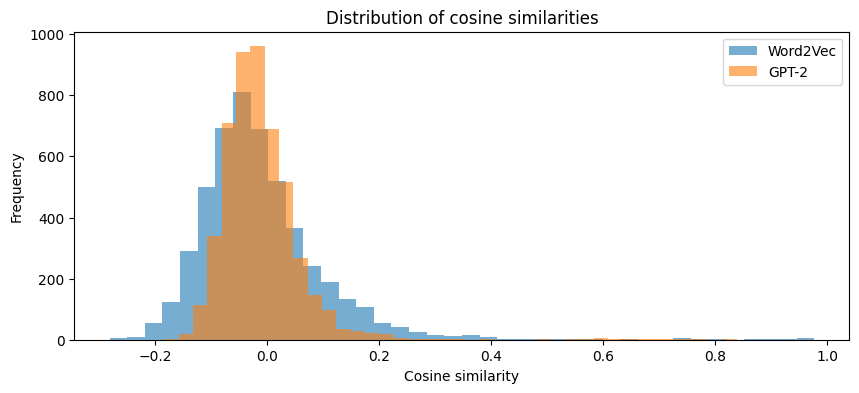

In [71]:
plt.figure(figsize=(10,4))

plt.hist(sc_w2v_centered[np.triu_indices_from(sc_w2v_centered, k=1)],
         bins=40, alpha=0.6, label="Word2Vec")

plt.hist(sc_gpt_centered[np.triu_indices_from(sc_gpt_centered, k=1)],
         bins=40, alpha=0.6, label="GPT-2")

plt.legend()
plt.title("Distribution of cosine similarities")
plt.xlabel("Cosine similarity")
plt.ylabel("Frequency")
plt.show()


In [72]:
# Get unique non-diagonal elements from the cosine similarity matrices
w2v_unique = sc_w2v[np.triu_indices_from(sc_w2v, k=1)]
gpt_unique = sc_gpt[np.triu_indices_from(sc_gpt, k=1)]

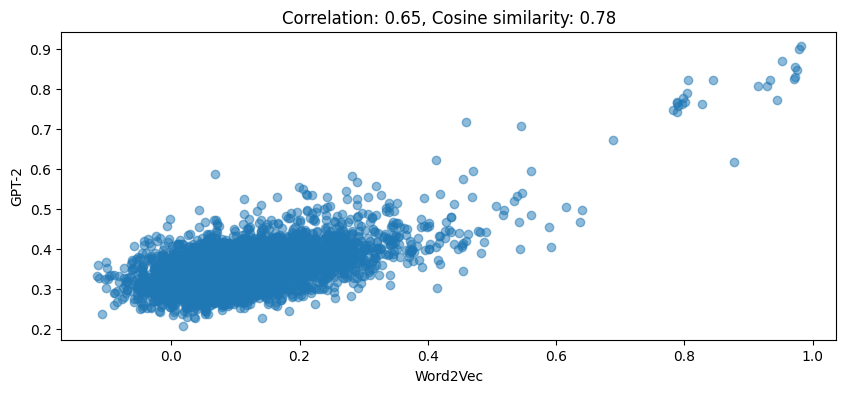

In [83]:
# Draw a scatter plot for cosine similarity matrices

r = np.corrcoef(w2v_unique, gpt_unique)[0,1]
sc = cosine_similarity(w2v_unique.reshape(1,-1), gpt_unique.reshape(1,-1))[0,0]

plt.figure(figsize=(10,4))
plt.scatter(w2v_unique, gpt_unique, alpha=0.5)
plt.xlabel("Word2Vec")
plt.ylabel("GPT-2")
plt.title(f"Correlation: {r:.2f}, Cosine similarity: {sc:.2f}")

plt.show()

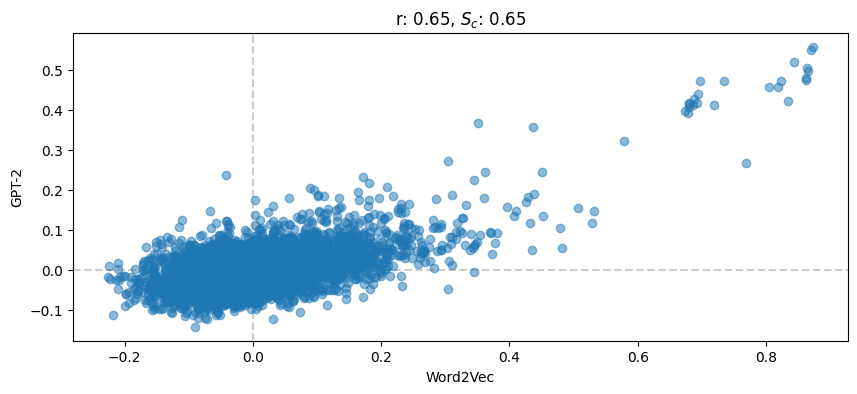

In [97]:
# Get unique non-diagonal elements from the mean offset cosine similarity matrices
w2v_unique_mean_offset = w2v_unique - w2v_unique.mean()
gpt_unique_mean_offset = gpt_unique - gpt_unique.mean()

# Draw a scatter plot for cosine similarity matrices

r = np.corrcoef(w2v_unique_mean_offset, gpt_unique_mean_offset)[0,1]
sc = cosine_similarity(w2v_unique_mean_offset.reshape(1,-1), gpt_unique_mean_offset.reshape(1,-1))[0,0]

plt.figure(figsize=(10,4))
plt.scatter(w2v_unique_mean_offset, gpt_unique_mean_offset, alpha=0.5)
plt.axhline(0, color=[.8,.8,.8], linestyle='--',zorder=-19)
plt.axvline(0, color=[.8,.8,.8], linestyle='--', zorder=-19)
plt.xlabel("Word2Vec")
plt.ylabel("GPT-2")
plt.title(f"r: {r:.2f}, $S_c$: {sc:.2f}")

plt.show()
